# Project 2-1: Lung Cancer Mortality by U.S. State (Python Replication)

**Author:** Tolulope  Oladeji
**Context:** Python replication of an ArcGIS Pro exercise from *GIS Tutorial for Health* (Kurland & Gorr).


---

## Objective

Reproduce the ArcGIS Pro workflow for visualizing male lung cancer mortality rates by U.S. state (2000–2004), using the National Cancer Institute (NCI) dataset. Specifically:

1. Load state-level lung cancer mortality data.
2. Identify the **top five states** with the highest mortality rates for **Black males** (`RBM00_04`) and **White males** (`RWM00_04`).
3. Produce a publication-quality choropleth-style map highlighting those states.
4. Export top-five summary tables.

## Data Dictionary

| Attribute   | Definition                                                |
|-------------|-----------------------------------------------------------|
| `RWM00_04`  | Mortality rate per 100,000 — White males, 2000–2004       |
| `RBM00_04`  | Mortality rate per 100,000 — Black males, 2000–2004       |

## ArcGIS Pro ↔ Python Workflow Mapping

| ArcGIS Pro step                          | Python equivalent                                |
|------------------------------------------|--------------------------------------------------|
| Add `LungState` layer                    | `gpd.read_file(gdb_path, layer="LungState")`     |
| Symbolize Hollow fill, gray outline      | `facecolor="none", edgecolor="dimgray"`          |
| Label states with halo mask              | `ax.annotate(...) + PathEffects.withStroke(...)` |
| Select top 5 by attribute                | `df.nlargest(5, "RBM00_04")`                     |
| 10% Simple hatch at 45° / 135°           | `hatch="///"` / `hatch="\\\\"`               |
| Export to JPEG                           | `fig.savefig(..., dpi=300, format="jpeg")`       |


In [24]:
# 1. Imports
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print(f"geopandas: {gpd.__version__}")
print(f"pandas:    {pd.__version__}")

geopandas: 1.0.1
pandas:    2.2.2


In [26]:
# 2. Configuration
# All paths are relative to the project root, so this notebook is portable
# across machines. To run, place the textbook data inside:
#     <project_root>/data/NCI.gdb
# The .gdb is intentionally not committed to GitHub — see .gitignore.

from pathlib import Path

# Detect project root automatically — works whether the notebook is launched
# from the project root or from inside the notebooks/ subdirectory.
HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE

# Folder layout (relative)
DATA_DIR   = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MAPS_DIR   = OUTPUT_DIR / "maps"
TABLES_DIR = OUTPUT_DIR / "tables"

# Dataset for this assignment
GDB_PATH = DATA_DIR / "NCI.gdb"
LAYER    = "LungState"

# Standard CONUS projection — Albers Equal Area Conic
CONUS_CRS = "EPSG:5070"

# Create output directories on first run (no-op if they already exist)
MAPS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Diagnostics ---
print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_DIR}")
print(f"   exists?   : {DATA_DIR.exists()}")
print(f"GDB path     : {GDB_PATH}")
print(f"   exists?   : {GDB_PATH.exists()}")

if not GDB_PATH.exists():
    print("\n NCI.gdb not found at the expected location.")
    print("    Fix: copy the entire NCI.gdb folder from your textbook data into:")
    print(f"          {DATA_DIR}")
    if DATA_DIR.exists():
        contents = sorted(DATA_DIR.iterdir())
        if contents:
            print(f"\n    Current contents of {DATA_DIR.name}/:")
            for item in contents:
                print(f"      - {item.name}")
        else:
            print(f"\n    The {DATA_DIR.name}/ folder exists but is empty.")

Project root : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)
Data folder  : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\data
   exists?   : True
GDB path     : C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\data\NCI.gdb
   exists?   : True


## Step 1: Load the state-level lung cancer data

We read the `LungState` feature class directly from the file geodatabase. GeoPandas uses the `pyogrio` (or `fiona`) backend to read ESRI `.gdb` files.

In [28]:
# 3. Load LungState feature class
# First, inspect what layers the .gdb actually contains — this catches
# typos in layer names and documents what else is available in the gdb.

import pyogrio

print(f"Available layers in {GDB_PATH.name}:")
layers_info = pyogrio.list_layers(GDB_PATH)
for layer_name, geom_type in layers_info:
    print(f"   - {layer_name:30s} ({geom_type})")

# Load the requested layer
print(f"\nLoading layer: {LAYER}")
lung_state = gpd.read_file(GDB_PATH, layer=LAYER)

print(f"\nRecords      : {len(lung_state)}")
print(f"Geometry type: {lung_state.geom_type.iloc[0]}")
print(f"Original CRS : {lung_state.crs}")
print(f"Columns      : {list(lung_state.columns)}")

lung_state.head(3)

Available layers in NCI.gdb:
   - BreCounty                      (MultiPolygon)
   - LungState                      (MultiPolygon)
   - LungCounty                     (MultiPolygon)
   - BreState                       (MultiPolygon)

Loading layer: LungState

Records      : 51
Geometry type: MultiPolygon
Original CRS : EPSG:4269
Columns      : ['ID_', 'NAME1_', 'NAME2_', 'POINTS_', 'LENGTH_', 'AREA_', 'RWM95_99', 'CWM95_99', 'RWF95_99', 'CWF95_99', 'RBM95_99', 'CBM95_99', 'RBF95_99', 'CBF95_99', 'RWM00_04', 'CWM00_04', 'RWF00_04', 'CWF00_04', 'RBM00_04', 'CBM_00_04', 'RBF00_04', 'CBF00_04', 'CWMBM95_99', 'CWFBF95_99', 'CWMBM00_04', 'CWFBF00_04', 'C_ALL_95_99', 'C_ALL_00_04', 'CHANGE_ALL_95_04', 'Shape_Length', 'Shape_Area', 'geometry']


,ID_,NAME1_,NAME2_,POINTS_,LENGTH_,AREA_,RWM95_99,CWM95_99,RWF95_99,CWF95_99,...,CWMBM95_99,CWFBF95_99,CWMBM00_04,CWFBF00_04,C_ALL_95_99,C_ALL_00_04,CHANGE_ALL_95_04,Shape_Length,Shape_Area,geometry
0,ST29,MO,Missouri,215,1397.494,68555.27,91.2655,10170.0,44.0403,6586.0,...,11217,7261,11221,7810,18478,19031,553.0,23.681271,18.618219,"MULTIPOLYGON (((-91.18219 39.59859, -91.04479 ..."
1,ST08,CO,Colorado,53,1325.434,106764.40,56.7180,3698.0,31.5302,2724.0,...,3838,2819,4037,3378,6657,7415,758.0,22.012247,28.031005,"MULTIPOLYGON (((-105.2199 36.9956, -105.71899 ..."
2,ST04,AZ,Arizona,80,1461.813,116381.00,66.6445,6726.0,38.4146,4798.0,...,6904,4883,7207,5609,11787,12816,1029.0,23.135508,28.934293,"MULTIPOLYGON (((-113.33319 32.039, -114.81279 ..."


In [30]:
# 4. Filter to contiguous U.S. and reproject
# Column conventions in this textbook dataset:
#   NAME1_ = state abbreviation (e.g., "MO", "CO")
#   NAME2_ = full state name (e.g., "Missouri", "Colorado")

STATE_COL = "NAME2_"   # full state name
ABBR_COL  = "NAME1_"   # state abbreviation

# Inspect what we have before filtering
print(f"All states in dataset: {sorted(lung_state[STATE_COL].unique())}")
print(f"Total records: {len(lung_state)}")

# Drop non-contiguous states for cartographic clarity
non_conus = {"Alaska", "Hawaii", "Puerto Rico", "Hawai'i"}
conus = lung_state[~lung_state[STATE_COL].isin(non_conus)].copy()

# Reproject to Albers Equal Area Conic — the standard CONUS projection
conus = conus.to_crs(CONUS_CRS)

print(f"\nCONUS records: {len(conus)}")
print(f"Projected CRS: {conus.crs}")

All states in dataset: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Total records: 51

CONUS records: 49
Projected CRS: EPSG:5070


In [32]:
# 5. Descriptive statistics — get a feel for the distributions
conus[["RWM00_04", "RBM00_04"]].describe().round(2)

,RWM00_04,RBM00_04
count,49.00,49.00
mean,73.57,89.92
std,15.19,26.64
min,34.98,17.75
25%,64.17,75.95
50%,72.30,95.29
75%,85.03,108.84
max,113.18,128.74


## Step 2: Identify top-five states by mortality rate

In ArcGIS Pro, this is *Select by Attributes* + manual sorting. In pandas, it is a one-liner.

In [35]:
# 6. Top 5 states by Black male lung cancer mortality (2000–2004)
top5_black = (conus.nlargest(5, "RBM00_04")
                   [[STATE_COL, "RBM00_04"]]
                   .reset_index(drop=True))
top5_black.columns = ["State", "Black Male Mortality Rate (per 100,000)"]
top5_black

,State,"Black Male Mortality Rate (per 100,000)"
0,Maine,128.7442
1,Nebraska,127.5898
2,Kentucky,125.4526
3,Louisiana,120.9052
4,Idaho,120.4409


In [37]:
# 7. Top 5 states by White male lung cancer mortality (2000–2004)
top5_white = (conus.nlargest(5, "RWM00_04")
                   [[STATE_COL, "RWM00_04"]]
                   .reset_index(drop=True))
top5_white.columns = ["State", "White Male Mortality Rate (per 100,000)"]
top5_white

,State,"White Male Mortality Rate (per 100,000)"
0,Kentucky,113.1761
1,Mississippi,101.3510
2,Tennessee,99.4980
3,Arkansas,98.2532
4,West Virginia,96.0647


In [39]:
# 8. Export tables (CSV for portability; Word doc can be assembled separately)
top5_black.to_csv(TABLES_DIR / "top5_black_male_mortality.csv", index=False)
top5_white.to_csv(TABLES_DIR / "top5_white_male_mortality.csv", index=False)
print(f"Tables saved to: {TABLES_DIR}")

Tables saved to: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\tables


## Step 3: Build the combined choropleth map

The ArcGIS Pro version uses **Simple hatch** symbology with directional fills (dark green at 45° for Black males, dark blue at 135° for White males). matplotlib does not offer exact angle-controlled hatches, but `///` and `\\\\` give the same visual signal and the legend disambiguates them clearly. States in the top-five for *both* groups will appear in both hatches stacked — these are precisely the high-burden states worth flagging in the report's "patterns observed" section.

Map exported: C:\Users\oladejta\OneDrive - University of Cincinnati\Desktop\GIS and Public Health\Python Implementation of GIS and Public health Course\files (4)\outputs\maps\Assignment2_1_Oladeji.jpg


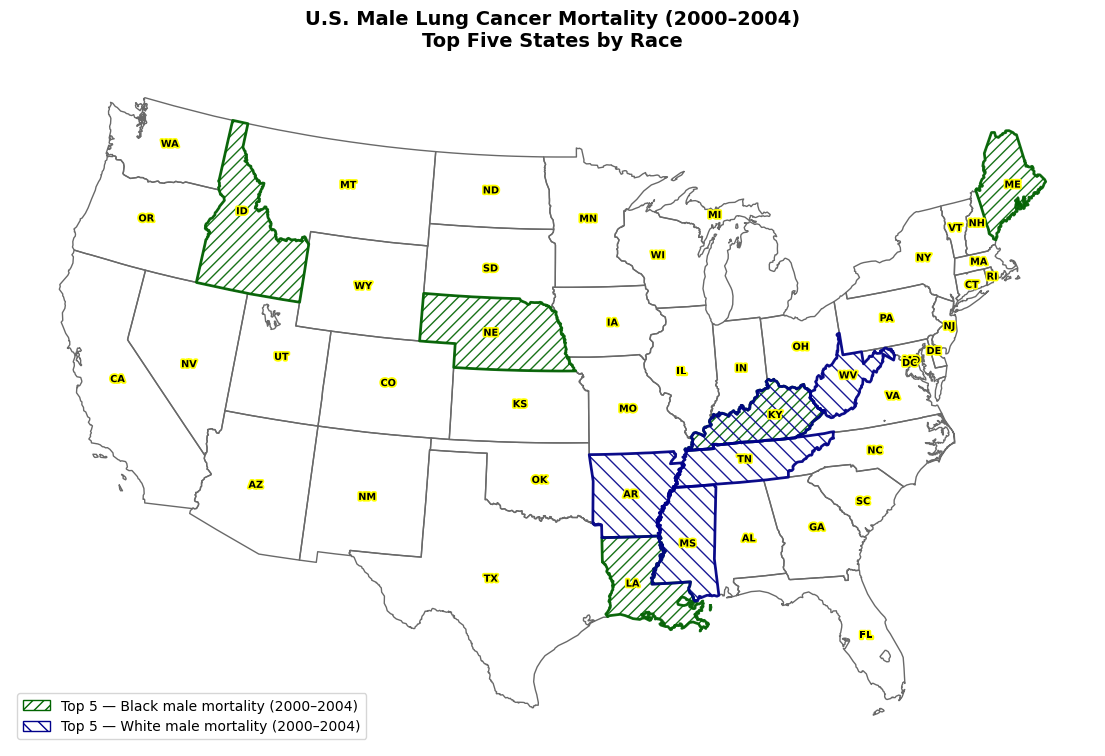

In [41]:
# 9. Build the publication-quality map
top5_black_states = set(top5_black["State"])
top5_white_states = set(top5_white["State"])

fig, ax = plt.subplots(figsize=(14, 9))

# Base layer: all CONUS states, hollow fill, medium-gray outline (matches the ArcGIS spec)
conus.plot(ax=ax, facecolor="none", edgecolor="dimgray", linewidth=1.0)

# Top 5 Black male: dark green, hatched (45° equivalent)
conus[conus[STATE_COL].isin(top5_black_states)].plot(
    ax=ax,
    facecolor="none",
    edgecolor="darkgreen",
    linewidth=2.0,
    hatch="///",
    alpha=0.9,
)

# Top 5 White male: dark blue, hatched (135° equivalent)
conus[conus[STATE_COL].isin(top5_white_states)].plot(
    ax=ax,
    facecolor="none",
    edgecolor="darkblue",
    linewidth=2.0,
    hatch="\\\\",
    alpha=0.9,
)

# State abbreviation labels with yellow halo (matches ArcGIS Pro 'yellow halo mask')
# Use STATE_ABBR if present; fall back to first 4 letters of STATE_NAME
abbr_col = "STATE_ABBR" if "STATE_ABBR" in conus.columns else STATE_COL
for _, row in conus.iterrows():
    centroid = row.geometry.representative_point()
    txt = ax.annotate(
        text=row[ABBR_COL],
        xy=(centroid.x, centroid.y),
        ha="center", va="center",
        fontsize=7, fontweight="bold", color="black",
    )
    txt.set_path_effects([PathEffects.withStroke(linewidth=2.5, foreground="yellow")])

# Legend (manual, since hatches need a custom legend)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="none", edgecolor="darkgreen", hatch="///",
          label="Top 5 — Black male mortality (2000–2004)"),
    Patch(facecolor="none", edgecolor="darkblue", hatch="\\\\",
          label="Top 5 — White male mortality (2000–2004)"),
]
ax.legend(handles=legend_elements, loc="lower left", frameon=True, fontsize=10)

ax.set_title(
    "U.S. Male Lung Cancer Mortality (2000–2004)\nTop Five States by Race",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_axis_off()

# Export
out_jpg = MAPS_DIR / "Assignment2_1_Oladeji.jpg"
fig.savefig(out_jpg, dpi=300, bbox_inches="tight", format="jpeg")
print(f"Map exported: {out_jpg}")

plt.show()

## Step 4: Patterns observed 

According to the analysis above, three patterns are worth highlighting in the deliverable :

Based on the analysis above, three patterns warrant explicit interpretation in the Word deliverable.
Geographic clustering of White male mortality: According to the top-five ranking, the highest White male lung cancer mortality rates concentrate in a contiguous Appalachian and Mid-South belt — Kentucky, West Virginia, Tennessee, Arkansas, and Mississippi. This spatial contiguity is itself a substantive finding, suggesting shared underlying determinants rather than random state-level variation. In line with the broader public health literature, this clustering aligns with documented patterns in historical smoking prevalence, occupational exposure in tobacco and coal-mining economies, and persistent disparities in screening access and early detection across the region.

Geographic dispersion of Black male mortality: In contrast, the top-five states for Black male mortality are spatially scattered — Idaho, Nebraska, Maine, Louisiana, and Mississippi. This dispersion is methodologically important: states such as Idaho, Maine, and Nebraska have very small Black populations, which means race-specific mortality rates are calculated from small denominators and are therefore statistically unstable. A small number of deaths can produce inflated or volatile rate estimates that do not reflect the underlying epidemiological burden. According to standard public health practice, rates derived from fewer than approximately 16 to 20 events are typically flagged or suppressed by surveillance agencies, including the National Center for Health Statistics. This caveat should be explicitly acknowledged when interpreting the ranking, and it points to the value of population-weighted or county-level analyses for more reliable race-stratified inference.

Overlap states as cross-population priority areas: Two states (Mississippi and Louisiana), appear in the top five for both White and Black male mortality, visible on the map as overlapping green and blue hatches. These overlap states represent the highest-priority targets for cross-population public health intervention, as the lung cancer burden is elevated across racial groups simultaneously. Kentucky also ranks among the highest White male mortality states and, based on the textbook narrative, exhibits comparably elevated Black male mortality at the county level — a pattern that motivates the finer-resolution analysis pursued in Assignment 2-2.


## Reproducibility & Portfolio Notes

- **Data:** Not committed to the repository. Source: NCI Cancer Mortality Maps (https://gis.cancer.gov). The packaged `.gdb` is from the *GIS Tutorial for Health* companion data.
- **Environment:** `geopandas >= 0.14`, `matplotlib >= 3.7`, `pandas >= 2.0`. Reading `.gdb` files requires `pyogrio` or `fiona` with GDAL ≥ 3.4.
- **Limitations of the Python replication:**
  - matplotlib hatches do not support arbitrary angle specification (only `/`, `\\`, `x`, `-`, `|`, `+`, `o`, `*`); the cartographic intent is preserved via the directional difference and the legend.
  - The yellow-halo state labels use `PathEffects.withStroke`, which approximates ArcGIS Pro's halo mask but does not exactly match its rendering algorithm.
- **Next step:** Assignment 2-2 extends this workflow to Kentucky counties — same data source, finer geography, added city overlay.